# Minimal to just run

In [8]:
%reset -f
# Load the autoreload extension and automatically reload all modules before executing code
%run setup_notebook.py
%run pylib/setup dark
from pylib import data_setup
from importlib import reload
from pylib import mc_dev; reload(mc_dev)
from pylib.mc_dev import (sim_design_thoughts, check_step, CellSim, BBsim, p_view, show, show_date, show_fig,
                          capture_hide, plt, sns, pd, np)

from pylib import cell; reload(cell)
from pylib.cell import Cell, CDFinverter
from wtlike import WtLike, Timer
show_date()

name = '4FGL J0056.3-0935' # strong single-step
show(f"""Choose {name} to use for MC study""")
with capture_hide(f'Source setup output for {name} with {(interval:=30)}-day itervals') as printout:
    wtl = WtLike(name, time_bins=(0,0,interval),clear=False)
show(printout)
show(f'Will use its `{len(wtl.photons)}` weight values for simulation') 
bb_full = wtl.bb_view()


<h5 style="text-align:right; margin-right:15px"> 2026-08-15 15:20</h5>

Choose 4FGL J0056.3-0935 to use for MC study

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7643a39c8980>

Will use its `85266` weight values for simulation

Bayesian Blocks: partitioning 218  cells using LikelihoodFitness with penalty 5%
	found 2 / 218 blocks.
LightCurve: Loaded 2 / 2 cells for fitting


# Examine the fit's dependence on the weight distribution



## Study behavior of the CDFInverter with a set of weights 

the CDFInverter compresses 85,266 weights to 3,145 points

The reconstructed weights exactly match the original.

This is because the original set of weights are discrete, coresponding to the set
of pixels.<br>      
I could have used this to perform sums over the original weights more efficiently.

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7643a39c86e0>
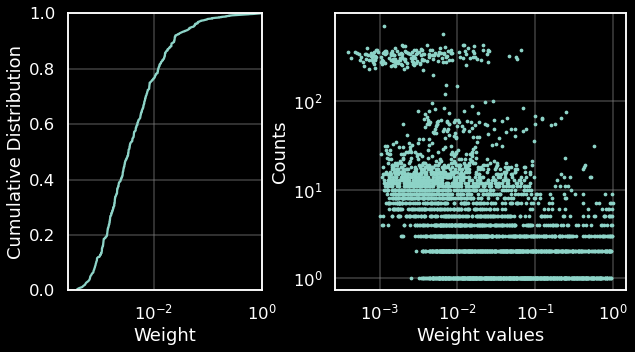

In [9]:
show(f""" ## Study behavior of the CDFInverter with a set of weights """)
w_full = np.sort(wtl.photons.weight.values).astype(np.float32)
cdi = CDFinverter(w_full); #cdi.plot();
show(f"the CDFInverter compresses {len(w_full):,} weights to {len(cdi.q):,} points")
counts = np.diff(np.insert(cdi.yq * len(w_full), 0, 0))
rw = cdi(np.linspace(0, 1, len(w_full)))
match = np.all(rw == w_full)
show(f"The reconstructed weights {'exactly match' if match else 'do not match'} the original.")
if not match:
    raise AssertionError("The reconstructed weights do not match the original.") 
show(f"""This is because the original set of weights are discrete, coresponding to the set
     of pixels.<br>      
     I could have used this to perform sums over the original weights more efficiently.""")

# fig, (ax1,ax2) = plt.subplots(ncols=2, figsize=(10, 5), 
#                         gridspec_kw={'width_ratios': [1, 1.5], "wspace": 0.3})
# cdi.plot(ax=ax1,label='');
# ax2.scatter(cdi.q, counts, marker='o', s=5)
# ax2.set(xscale='log', xlabel='Weight values', ylabel='Counts', yscale='log')
# plt.show()

show_fig(cdi.multi_plot, )

In [39]:
first = Cell(bb_full.cells.iloc[0], name='first')
last  = Cell(bb_full.cells.iloc[-1], name='last')
full = Cell(pd.Series(wtl.concatenate()), name='full')
cells = (first, last, full)
show(f"""### Defined cells:\n{'<br>'.join(str(cell) for cell in cells)}""")
show(np.sort(full.w))

from pylib.cell import Cell, CDFinverter
test_cell = full
show(f""" Using cell "{test_cell.name}", try setting its weight sampler to each in turn: """)
show(test_cell)

for cell in cells:
    test_cell.weight_sampler = CDFinverter(cell.w)
    resample = test_cell.non_random(test_cell.name+f" using {cell.name}'s weight sampler")
    show(resample)

### Defined cells:
Cell name="first" flux=0.773 +/- 0.065, 50736 weights<br>Cell name="last" flux=1.352 +/- 0.099, 34291 weights<br>Cell name="full" flux=0.997 +/- 0.056, 85027 weights

array([3.912449e-04, 3.912449e-04, 3.912449e-04, ..., 9.916992e-01,
       9.916992e-01, 9.916992e-01], dtype=float32)

Using cell "full", try setting its weight sampler to each in turn: 

Cell name="full" flux=0.997 +/- 0.056, 85027 weights

Cell name="full using first's weight sampler" flux=0.817 +/- 0.052, 85027 weights

Cell name="full using last's weight sampler" flux=1.265 +/- 0.060, 85027 weights

Cell name="full using full's weight sampler" flux=0.997 +/- 0.056, 85027 weights

In [40]:
show(f"""## Simulate the large cells, to check errors
    With {(N:=4000)} trials each.""")

from multiprocessing import Pool

def run_sim(cell):
    return  np.array([Cell(CellSim(cell)(cell,inplace=False)).flux for _ in range(N)])

with Timer() as et:
    with Pool(len(cells)) as pool:
        fluxes = pool.map(run_sim, cells)
show(et)


## Simulate the large cells, to check errors
With 4000 trials each.

elapsed time: 106.0s (1.8 min)

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x78cb63d7da90>
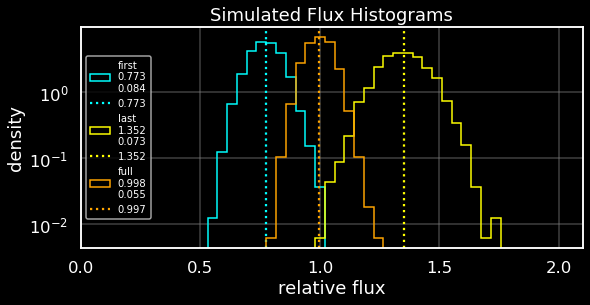

In [41]:
def plot_flux_histograms():
    """For a source with two blocks, plot histograms of the simulated fluxes 
    
    for the first, last, and full, or combined cells. 
    The legend shows the mean and relative standard deviation of each histogram, 
    with the generated flux indicated by a vertical dotted line.
    """

    hkw = dict(bins=np.linspace(0,2,50), histtype='step')
    fig, ax = plt.subplots(figsize=(9,4))
    for fx, color, cell in zip( fluxes, 'cyan yellow orange'.split(), cells):
        ax.hist(fx,**hkw, label=f"{cell.name}\n{fx.mean():.3f}\n{fx.std()/fx.mean():.3f}", color=color, 
        log=True, density=True);
        ax.axvline((genf:=Cell(cell).flux), ls=':', color=color, label=f'{genf:.3f}')

    ax.legend(fontsize=10, loc='center left')
    ax.set(xlabel='relative flux', ylabel='density', title='Simulated Flux Histograms', 
           xticks=np.arange(0,2.1,0.5),xlim=(0,None))
    return fig

show_fig(plot_flux_histograms, fignum=None)

## Compare the first and last cell weight distributions

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x78cb63d7f4d0>
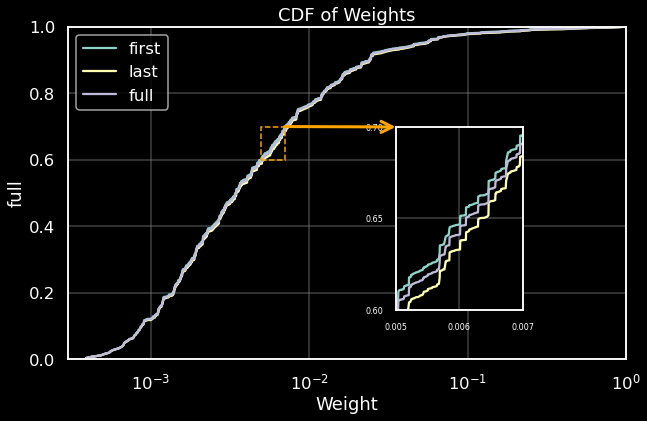

In [42]:
show(f"""## Compare the first and last cell weight distributions""")

def plot_cells_cumulative(cells,):
    """
    Overlay of the cumulative weight distributions for the first and last blocks, as well as the full cell. 
    The inset shows a zoomed-in view of the region highlighted by the orange dashed box on the main plot.
    """
    from matplotlib.patches import Rectangle, ConnectionPatch
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    # Main plot
    for cell in cells:
        cell.plot_cumulative(ax=ax1, label=cell.name)
    ax1.set(xlim=(3e-4,1))
    ax1.legend(loc='upper left')

    # Inset (zoom)
    axins = inset_axes(ax1, width="42%", height="55%", loc="lower right", borderpad=3)
    for cell in cells:
        cell.plot_cumulative(ax=axins)

    axins.set(
        xlim=(5e-3, 7e-3),
        ylim=(0.6, 0.7),
        xscale='linear', xlabel='',
        ylabel='',
        yticks=np.arange(0.6, 0.71, 0.05),
        xticks=np.arange(5e-3, 7.1e-3, 1e-3),
        title=''
    )
    axins.tick_params(labelsize=8)

    # Box on main plot showing inset region
    x0, x1 = axins.get_xlim()
    y0, y1 = axins.get_ylim()
    zoom_box = Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        fill=False, edgecolor='orange', linestyle='--', linewidth=1.5, zorder=10
    )
    ax1.add_patch(zoom_box)

    # Match inset physical aspect ratio to the zoom box on ax1
    fig.canvas.draw()  # ensure transforms/bboxes are current
    p0 = ax1.transData.transform((x0, y0))
    p1 = ax1.transData.transform((x1, y1))
    box_aspect = abs((p1[1] - p0[1]) / (p1[0] - p0[0]))  # height / width in pixels
    axins.set_box_aspect(box_aspect)

    # Arrow from zoom box to inset
    con = ConnectionPatch(
        xyA=(x1, y1), coordsA=ax1.transData,
        xyB=(0, 1), coordsB=axins.transAxes,
        arrowstyle='->', color='orange', lw=3,
        mutation_scale=28,
    )
    fig.add_artist(con)
    return fig


show_fig(plot_cells_cumulative, [first, last, full])
caption="""
Overlay of the cumulative weight distributions for the first and last blocks, as well as the full cell. 
The inset shows a zoomed-in view of the region highlighted by the orange dashed box on the main plot.
"""